In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path

PROCESSED = Path("../data/processed")
REPORTS = Path("../reports")
REPORTS.mkdir(exist_ok=True)

# Load data
nav = pd.read_csv(PROCESSED / "clean_nav_history.csv")
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

bench = pd.read_csv(PROCESSED / "clean_10_benchmark_indices.csv")
bench['date'] = pd.to_datetime(bench['date'])

fund_master = pd.read_csv(PROCESSED / "clean_01_fund_master.csv")

print("✅ Data loaded!")
print(f"NAV rows: {len(nav)}")
print(f"Funds: {nav['amfi_code'].nunique()}")

✅ Data loaded!
NAV rows: 46000
Funds: 40


In [2]:
# CELL 2: Compute Daily Returns and CAGR
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

def compute_cagr(group, years):
    group = group.sort_values('date')
    end_date = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    period = group[group['date'] >= start_date]
    if len(period) < 2:
        return None
    nav_start = period['nav'].iloc[0]
    nav_end = period['nav'].iloc[-1]
    n = years
    return (nav_end / nav_start) ** (1/n) - 1

cagr_results = []
for code, group in nav.groupby('amfi_code'):
    cagr_results.append({
        'amfi_code': code,
        'cagr_1yr': compute_cagr(group, 1),
        'cagr_3yr': compute_cagr(group, 3),
        'cagr_5yr': compute_cagr(group, 5),
    })

cagr_df = pd.DataFrame(cagr_results)
cagr_df.to_csv(REPORTS / "cagr_report.csv", index=False)
print(cagr_df.head(10).to_string())
print("✅ CAGR computed!")

   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr
0     100016 -0.022243  0.012926  0.023168
1     100025  0.037050  0.039164  0.039127
2     100033  0.532324  0.324425  0.260741
3     101206  0.479241  0.289677  0.204427
4     101207 -0.239860 -0.041524  0.069533
5     101208  0.072366  0.063158  0.057057
6     102885  0.202077  0.196673  0.158788
7     102886 -0.167975 -0.007674  0.010303
8     102887  0.135831  0.255562  0.146781
9     118632  0.339810  0.226524  0.208811
✅ CAGR computed!


In [3]:
# CELL 3: Sharpe and Sortino Ratio
RF = 0.065 / 252  # RBI repo rate daily

metrics = []
for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < 30:
        continue
    
    # Sharpe Ratio
    excess = returns - RF
    sharpe = (excess.mean() / returns.std()) * np.sqrt(252)
    
    # Sortino Ratio
    downside = returns[returns < 0]
    sortino = (excess.mean() / downside.std()) * np.sqrt(252) if len(downside) > 0 else None
    
    # Max Drawdown
    nav_series = group.set_index('date')['nav']
    rolling_max = nav_series.cummax()
    drawdown = (nav_series / rolling_max) - 1
    max_dd = drawdown.min()
    
    metrics.append({
        'amfi_code': code,
        'sharpe_ratio': round(sharpe, 4),
        'sortino_ratio': round(sortino, 4) if sortino else None,
        'max_drawdown': round(max_dd, 4),
        'ann_return': round(returns.mean() * 252, 4),
        'ann_volatility': round(returns.std() * np.sqrt(252), 4),
    })

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(REPORTS / "sharpe_sortino.csv", index=False)
print(metrics_df.head(10).to_string())
print("✅ Sharpe & Sortino done!")

   amfi_code  sharpe_ratio  sortino_ratio  max_drawdown  ann_return  ann_volatility
0     100016       -0.2015        -0.3510       -0.2473      0.0357          0.1455
1     100025       -0.5671        -0.9418       -0.0431      0.0429          0.0391
2     100033        1.0937         1.8291       -0.1622      0.2721          0.1894
3     101206        1.0272         1.7996       -0.1129      0.2146          0.1457
4     101207        0.1627         0.2766       -0.3545      0.1070          0.2580
5     101208       -0.8156        -1.6810       -0.0016      0.0609          0.0051
6     102885        0.8171         1.4357       -0.1086      0.1699          0.1284
7     102886       -0.2058        -0.3472       -0.2800      0.0277          0.1813
8     102887        0.6195         1.0888       -0.2154      0.1626          0.1576
9     118632        1.0817         1.8501       -0.1741      0.2180          0.1415
✅ Sharpe & Sortino done!


In [4]:
# CELL 4: Alpha and Beta vs Nifty 100
print(bench.columns.tolist())
print(bench['index_name'].unique())

['date', 'index_name', 'close_value']
['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [5]:
# CELL 5: Maximum Drawdown already computed above
# Now compute Alpha & Beta
nifty100 = bench[bench['index_name'] == 'NIFTY100'][['date', 'close_value']].copy()
nifty100 = nifty100.sort_values('date')
nifty100['bench_return'] = nifty100['close_value'].pct_change()

alpha_beta = []
for code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date')
    merged = pd.merge(group[['date','daily_return']], 
                      nifty100[['date','bench_return']], 
                      on='date', how='inner').dropna()
    if len(merged) < 30:
        continue
    slope, intercept, r, p, se = stats.linregress(
        merged['bench_return'], merged['daily_return'])
    alpha_beta.append({
        'amfi_code': code,
        'alpha': round(intercept * 252, 4),
        'beta': round(slope, 4),
        'r_squared': round(r**2, 4)
    })

ab_df = pd.DataFrame(alpha_beta)
ab_df.to_csv(REPORTS / "alpha_beta.csv", index=False)
print(ab_df.head(10).to_string())
print("✅ Alpha & Beta done!")

   amfi_code   alpha    beta  r_squared
0     100016  0.0375 -0.0583     0.0027
1     100025  0.0428  0.0012     0.0000
2     100033  0.2720  0.0051     0.0000
3     101206  0.2140  0.0211     0.0003
4     101207  0.1090 -0.0653     0.0011
5     101208  0.0609  0.0003     0.0000
6     102885  0.1705 -0.0195     0.0004
7     102886  0.0290 -0.0421     0.0009
8     102887  0.1621  0.0167     0.0002
9     118632  0.2183 -0.0084     0.0001
✅ Alpha & Beta done!


In [6]:
# CELL 6: Fund Scorecard (0-100)
scorecard = metrics_df.merge(cagr_df, on='amfi_code')
scorecard = scorecard.merge(ab_df, on='amfi_code')
scorecard = scorecard.merge(
    fund_master[['amfi_code','scheme_name','fund_house','expense_ratio_pct']], 
    on='amfi_code')

# Rank each metric
scorecard['rank_3yr'] = scorecard['cagr_3yr'].rank(ascending=True)
scorecard['rank_sharpe'] = scorecard['sharpe_ratio'].rank(ascending=True)
scorecard['rank_alpha'] = scorecard['alpha'].rank(ascending=True)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=False)
scorecard['rank_maxdd'] = scorecard['max_drawdown'].rank(ascending=False)

# Composite score
scorecard['score'] = (
    0.30 * scorecard['rank_3yr'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_maxdd']
)

# Normalize to 0-100
scorecard['final_score'] = (
    (scorecard['score'] - scorecard['score'].min()) /
    (scorecard['score'].max() - scorecard['score'].min()) * 100
).round(2)

scorecard = scorecard.sort_values('final_score', ascending=False)
scorecard.to_csv(REPORTS / "fund_scorecard.csv", index=False)

print("\n🏆 TOP 10 FUNDS BY SCORECARD:")
print(scorecard[['scheme_name','final_score',
    'cagr_3yr','sharpe_ratio','alpha']].head(10).to_string())
print("✅ Scorecard done!")


🏆 TOP 10 FUNDS BY SCORECARD:
                                           scheme_name  final_score  cagr_3yr  sharpe_ratio   alpha
25            ICICI Pru Midcap Fund - Regular - Growth       100.00  0.317775        1.1801  0.2926
16                 Axis Midcap Fund - Regular - Growth        94.20  0.351118        0.9982  0.2608
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth        93.82  0.324425        1.0937  0.2720
34       Mirae Asset Large Cap Fund - Regular - Growth        93.04  0.340009        1.4483  0.2698
30              Kotak Flexicap Fund - Regular - Growth        90.34  0.295828        1.3067  0.2733
24           ICICI Pru Bluechip Fund - Direct - Growth        86.47  0.324874        1.0265  0.2119
21          SBI Small Cap Fund - Regular Plan - Growth        85.51  0.266699        0.9453  0.3034
39               DSP Small Cap Fund - Regular - Growth        85.22  0.270004        0.9498  0.3006
36       Mirae Asset Tax Saver Fund - Regular - Growth        83.67  0

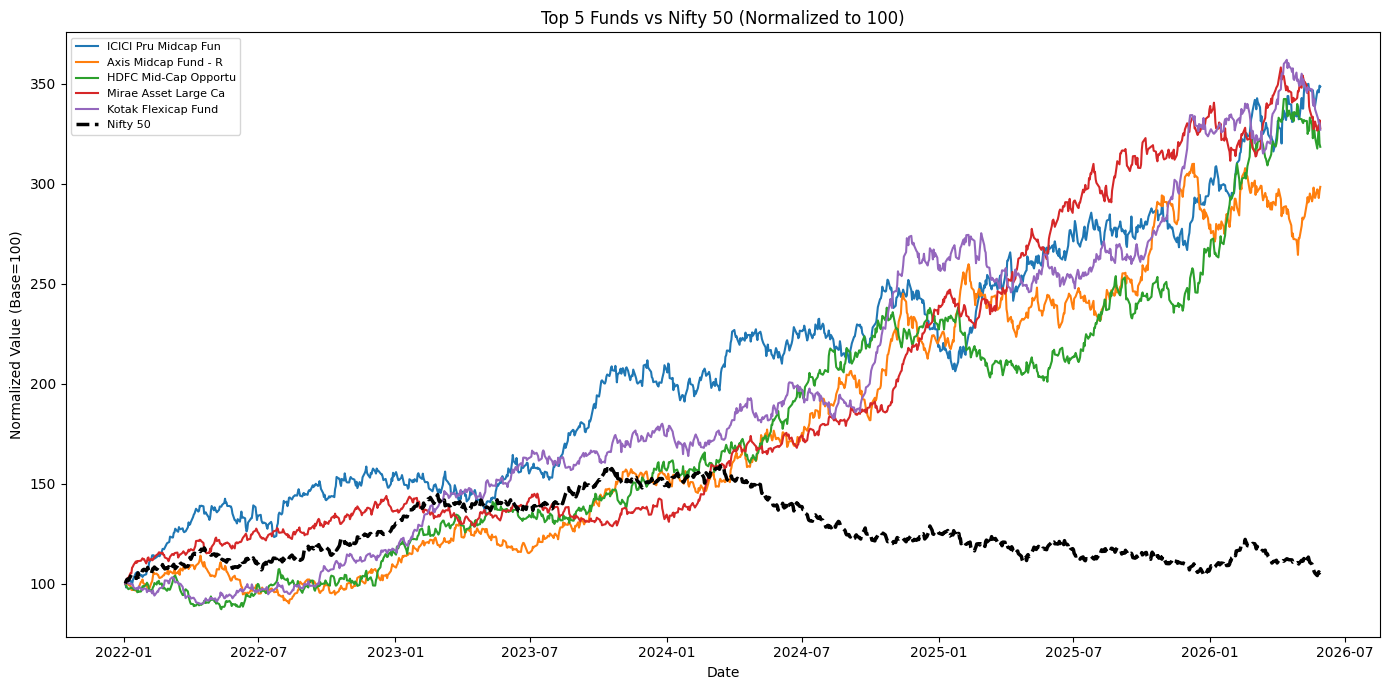

✅ Benchmark chart done!


In [7]:
# CELL 7: Benchmark Comparison Chart
import matplotlib.pyplot as plt

# Get Nifty 50 benchmark
nifty50 = bench[bench['index_name'] == 'NIFTY50'][['date','close_value']].copy()
nifty50 = nifty50.sort_values('date')

# Get top 5 funds from scorecard
top5_codes = scorecard['amfi_code'].head(5).tolist()
top5_names = scorecard.set_index('amfi_code')['scheme_name'].head(5).to_dict()

plt.figure(figsize=(14, 7))

# Plot top 5 funds (normalized to 100)
for code in top5_codes:
    fund_data = nav[nav['amfi_code'] == code].sort_values('date')
    fund_data = fund_data[fund_data['date'] >= '2022-01-01']
    if len(fund_data) == 0:
        continue
    normalized = fund_data['nav'] / fund_data['nav'].iloc[0] * 100
    plt.plot(fund_data['date'], normalized, 
             label=str(top5_names.get(code, code))[:20], linewidth=1.5)

# Plot Nifty 50 normalized
nifty50 = nifty50[nifty50['date'] >= '2022-01-01']
nifty_norm = nifty50['close_value'] / nifty50['close_value'].iloc[0] * 100
plt.plot(nifty50['date'], nifty_norm, 
         label='Nifty 50', linewidth=2.5, 
         color='black', linestyle='--')

plt.title('Top 5 Funds vs Nifty 50 (Normalized to 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Value (Base=100)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS / "benchmark_chart.png")
plt.show()
print("✅ Benchmark chart done!")

In [8]:
# CELL 8: Tracking Error
tracking_errors = []
for code in top5_codes:
    fund_data = nav[nav['amfi_code'] == code].sort_values('date')
    merged = pd.merge(
        fund_data[['date','daily_return']],
        nifty100[['date','bench_return']],
        on='date', how='inner').dropna()
    
    diff = merged['daily_return'] - merged['bench_return']
    tracking_error = diff.std() * np.sqrt(252)
    tracking_errors.append({
        'amfi_code': code,
        'scheme_name': top5_names.get(code, code),
        'tracking_error': round(tracking_error, 4)
    })

te_df = pd.DataFrame(tracking_errors)
print("\n📊 Tracking Error vs Nifty 100:")
print(te_df.to_string())

# Save all results
print("\n\n🏆 FINAL PERFORMANCE SUMMARY:")
print(scorecard[['scheme_name','final_score',
    'cagr_1yr','cagr_3yr','sharpe_ratio',
    'alpha','beta','max_drawdown']].head(10).to_string())

te_df.to_csv(REPORTS / "tracking_error.csv", index=False)



📊 Tracking Error vs Nifty 100:
   amfi_code                                         scheme_name  tracking_error
0     120505            ICICI Pru Midcap Fund - Regular - Growth          0.2320
1     119094                 Axis Midcap Fund - Regular - Growth          0.2377
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Growth          0.2287
3     148567       Mirae Asset Large Cap Fund - Regular - Growth          0.1897
4     120843              Kotak Flexicap Fund - Regular - Growth          0.2064


🏆 FINAL PERFORMANCE SUMMARY:
                                           scheme_name  final_score  cagr_1yr  cagr_3yr  sharpe_ratio   alpha    beta  max_drawdown
25            ICICI Pru Midcap Fund - Regular - Growth       100.00  0.296047  0.317775        1.1801  0.2926  0.0005       -0.1819
16                 Axis Midcap Fund - Regular - Growth        94.20  0.222611  0.351118        0.9982  0.2608 -0.0663       -0.2096
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth 